# Loading the Data

In [1]:
import sys
sys.path.append("../src")

from finance_analyzer.loader import load_data
from finance_analyzer.cleaner import clean_transactions

raw_data = load_data("../data/raw/janauary-data.csv")
df = clean_transactions(raw_data)
df

Data loaded successfully from ../data/raw/janauary-data.csv


,timestamp,type,description,amount,balance,date,time,day_of_week,week,month_day,direction
0,2026-01-02 00:42:00,Raast In,Incoming fund transfer from Iqra Irfan,25000.00,25028.91,2026-01-02,00:42:00,Friday,1,Jan 02,IN
1,2026-01-02 13:26:00,Raast Out,Outgoing fund transfer to Concordia 2,-160.00,24868.91,2026-01-02,13:26:00,Friday,1,Jan 02,OUT
2,2026-01-02 21:42:00,Raast Out,Outgoing fund transfer to Haseeb Ahmed,-960.00,23908.91,2026-01-02,21:42:00,Friday,1,Jan 02,OUT
3,2026-01-02 22:30:00,Raast Out,Outgoing fund transfer to Imad Ali Shah,-830.00,23078.91,2026-01-02,22:30:00,Friday,1,Jan 02,OUT
4,2026-01-03 07:07:00,Mobile Top-Up,Mobile top-up purchased |Ufone 03346086261,-200.00,22878.91,2026-01-03,07:07:00,Saturday,1,Jan 03,OUT
5,2026-01-03 12:04:00,Retail Payment,Paid to CRUSTEEZ|Raast,-1350.00,21528.91,2026-01-03,12:04:00,Saturday,1,Jan 03,OUT
6,2026-01-03 16:07:00,Raast Out,Outgoing fund transfer to Shan Muhammad,-700.00,20828.91,2026-01-03,16:07:00,Saturday,1,Jan 03,OUT
7,2026-01-03 18:47:00,Raast In,Incoming fund transfer from Muhammad Hassan Ali,436.00,21264.91,2026-01-03,18:47:00,Saturday,1,Jan 03,IN
8,2026-01-04 14:03:00,Raast Out,Outgoing fund transfer to Tayyab Bin Kashif,-705.00,20559.91,2026-01-04,14:03:00,Sunday,1,Jan 04,OUT
9,2026-01-04 23:13:00,Raast Out,Outgoing fund transfer to Zaid Ahmad Siddiqui,-500.00,20059.91,2026-01-04,23:13:00,Sunday,1,Jan 04,OUT


# Summary

In [2]:
from finance_analyzer.analyzer import get_summary
summary = get_summary(df)
for key, value in summary.items():
    print(f"{key}: {value:,}")

total_income: 30,296.0
total_spent: 28,670.31
net: 58,966.31
total_transactions: 31
average_transaction: 52.44


# Spending By Type

In [3]:
from finance_analyzer.analyzer import spending_by_type
spending_by_type(df)

,total,count
type,,
Raast Out,26452.00,20
Retail Payment,1350.00,1
Mobile Top-Up,600.00,3
Online,268.31,1


# Spending By Day

In [4]:
from finance_analyzer.analyzer import spending_by_day
spending_by_day(df)

,total
day_of_week,
Monday,16370.00
Tuesday,3290.00
Wednesday,725.00
Thursday,932.00
Friday,3630.00
Saturday,2518.31
Sunday,1205.00


# Biggest Expenses 

In [5]:
from finance_analyzer.analyzer import biggest_expenses
biggest_expenses(df)

,date,description,type,amount
11,2026-01-12,Outgoing fund transfer to Muhammad Musa Riaz,Raast Out,15000.0
17,2026-01-20,Outgoing fund transfer to Muhammad Noman Chaudhry,Raast Out,2000.0
15,2026-01-16,Outgoing fund transfer to Jawad Khalid,Raast Out,1630.0
5,2026-01-03,Paid to CRUSTEEZ|Raast,Retail Payment,1350.0
25,2026-01-27,Outgoing fund transfer to Nust Sports Ac,Raast Out,1000.0


# Balance Over Time


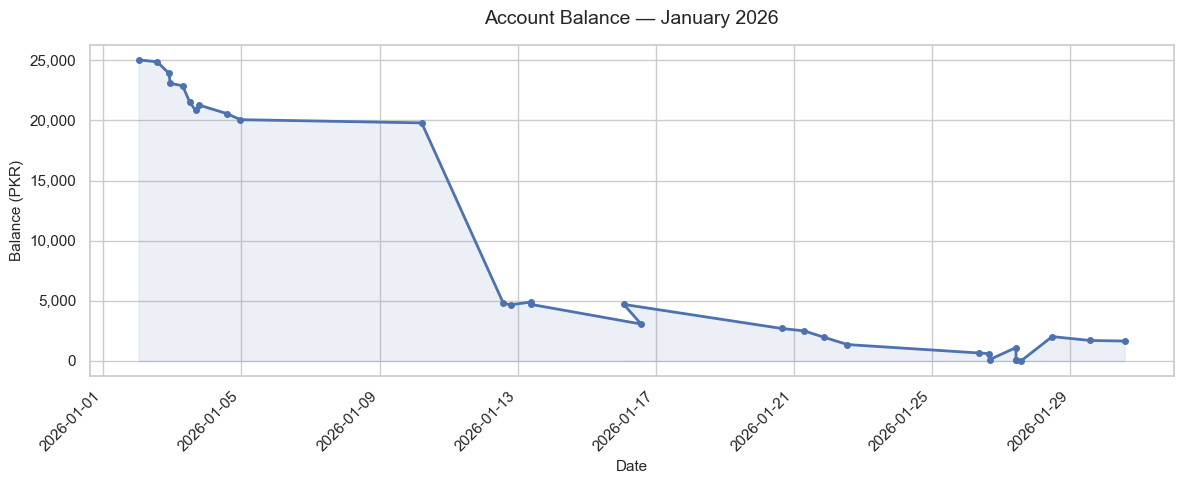

In [6]:
from finance_analyzer.visualizer import (
    balance_over_time,
    plot_spending_by_type,
    plot_daily_spending,
    plot_income_vs_spending,
)
balance_over_time(df)

# Spending By Type

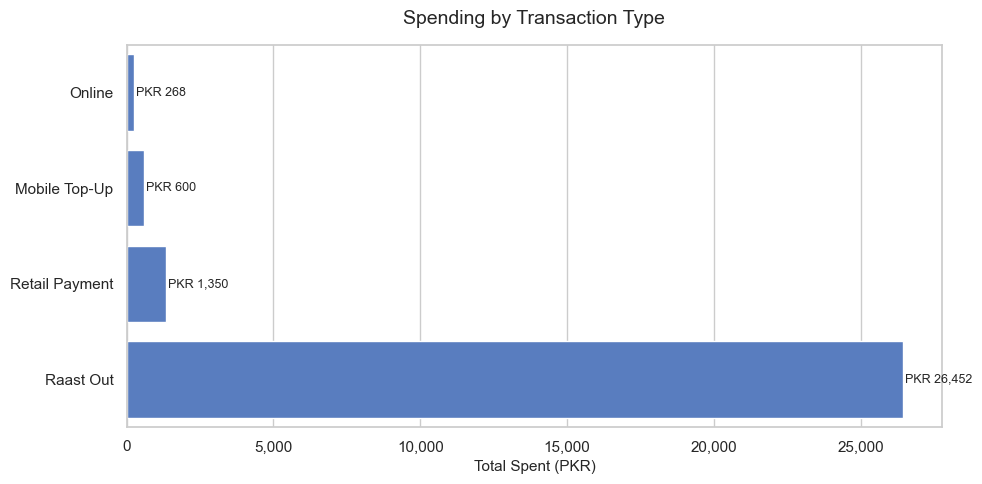

In [7]:
plot_spending_by_type(df)

# Daily Spending

C:\Users\Home PC\OneDrive\Desktop\finance-analyzer\notebooks\../src\finance_analyzer\visualizer.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


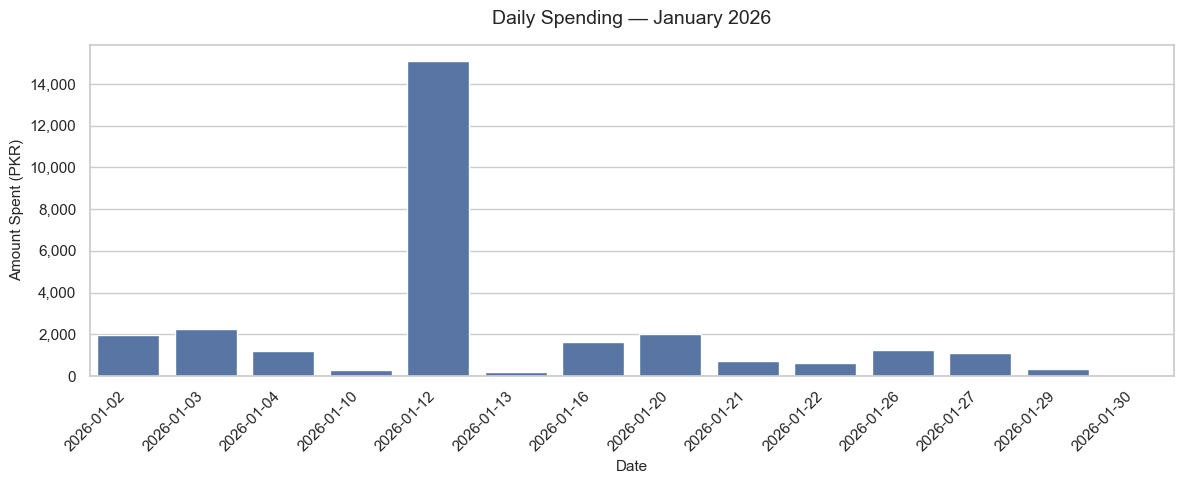

In [8]:
plot_daily_spending(df)

# Income Vs Spending

C:\Users\Home PC\OneDrive\Desktop\finance-analyzer\notebooks\../src\finance_analyzer\visualizer.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


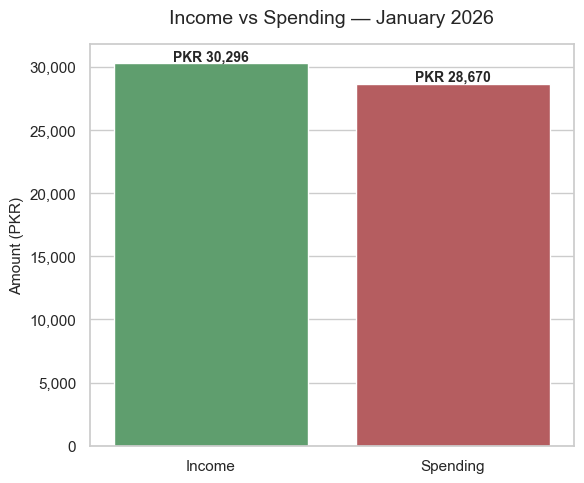

In [9]:
plot_income_vs_spending(df)

# Load Multiple Months

In [10]:
from finance_analyzer.loader import load_multiple_months
from finance_analyzer.cleaner import clean_transactions, add_month_column
raw_combined = load_multiple_months("../data/raw/")
df_all = clean_transactions(raw_combined)
df_all = add_month_column(df_all)

# Quick check — how many rows per month?
#
print(df_all.groupby("month_label").size())

total number of files ['Feburaury-data.csv', 'janauary-data.csv']
Data loaded successfully from ../data/raw/Feburaury-data.csv
Data loaded successfully from ../data/raw/janauary-data.csv
month_label
Feb 2026    29
Jan 2026    31
dtype: int64


# Monthly Summary Table

In [11]:
from finance_analyzer.analyzer import (
monthly_summary,
spending_by_type_summary,
top_recipients
)

summary = monthly_summary(df_all)
summary

,month,month_label,total_income,total_spent,net,num_transactions,avg_transaction
0,2026-01,Jan 2026,30296.0,28670.31,1625.69,31,1902.14
1,2026-02,Feb 2026,26200.0,27426.54,-1226.54,29,1849.19


# Monthly Charts

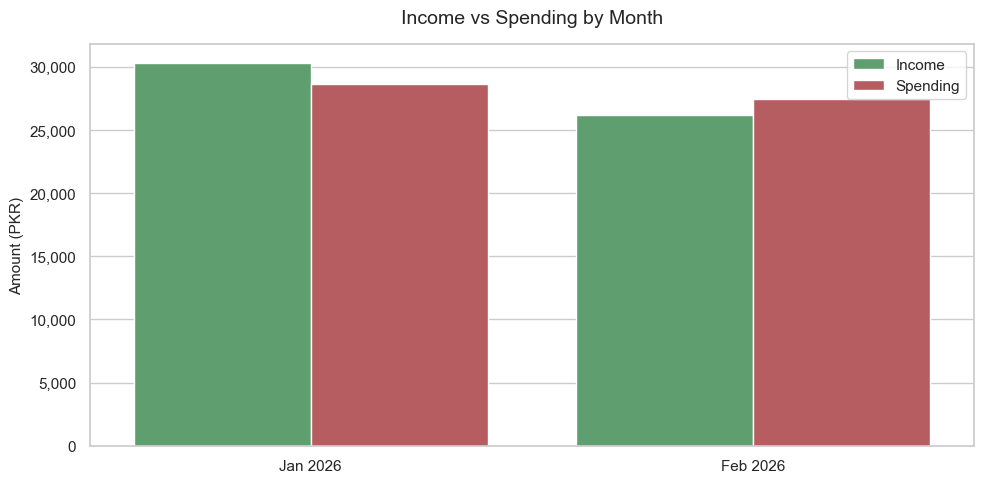

In [12]:
from finance_analyzer.visualizer import (
    plot_monthly_income_vs_spending,
    plot_monthly_net,
    plot_top_recipients,
)

plot_monthly_income_vs_spending(summary)

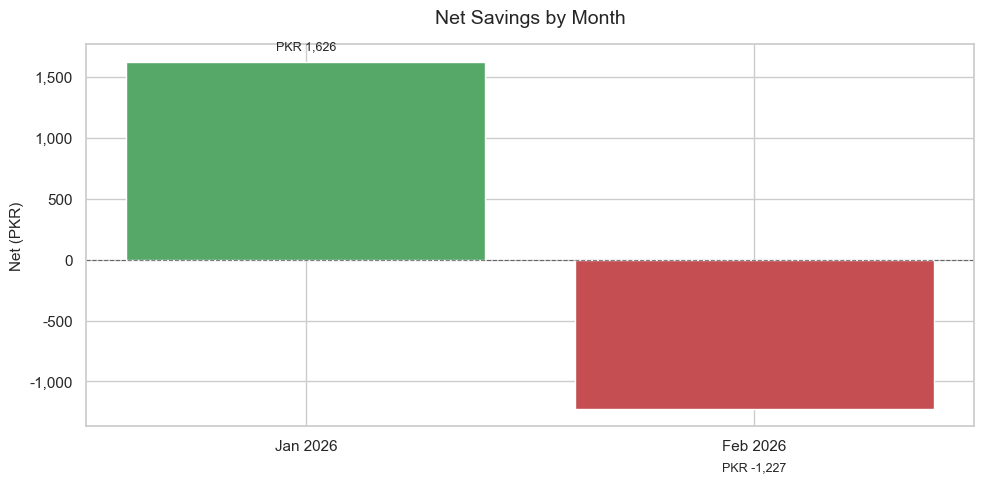

In [13]:
plot_monthly_net(summary)

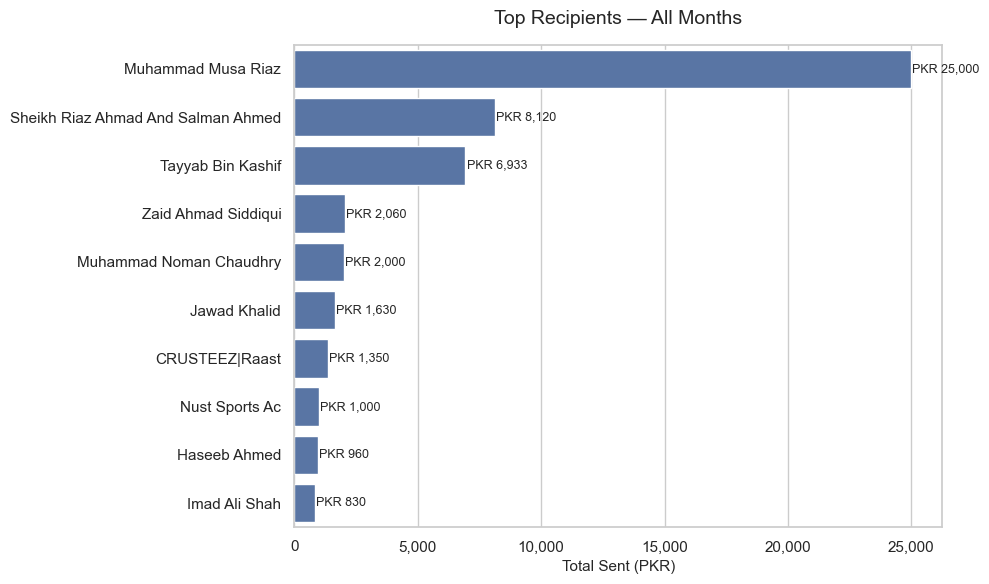

In [14]:
plot_top_recipients(df_all)

# Run Categorization

In [15]:
from finance_analyzer.ml import cluster_transactions

df_categorized = cluster_transactions(df_all, n_clusters=6)

# See what categories got assigned
df_categorized[["timestamp", "description", "amount", "category"]].head(20)

,timestamp,description,amount,category
0,2026-01-02 00:42:00,Incoming fund transfer from Iqra Irfan,25000.00,Transfer — Raast In
1,2026-01-02 13:26:00,Outgoing fund transfer to Concordia 2,-160.00,Transfer — Raast Out
2,2026-01-02 21:42:00,Outgoing fund transfer to Haseeb Ahmed,-960.00,Transfer — Raast Out
3,2026-01-02 22:30:00,Outgoing fund transfer to Imad Ali Shah,-830.00,Transfer — Raast Out
4,2026-01-03 07:07:00,Mobile top-up purchased |Ufone 03346086261,-200.00,Mobile Top-Up
5,2026-01-03 12:04:00,Paid to CRUSTEEZ|Raast,-1350.00,Food & Dining
6,2026-01-03 16:07:00,Outgoing fund transfer to Shan Muhammad,-700.00,Transfer — Raast Out
7,2026-01-03 18:47:00,Incoming fund transfer from Muhammad Hassan Ali,436.00,Transfer — Raast Out
8,2026-01-04 14:03:00,Outgoing fund transfer to Tayyab Bin Kashif,-705.00,Transfer — Raast Out
9,2026-01-04 23:13:00,Outgoing fund transfer to Zaid Ahmad Siddiqui,-500.00,Transfer — Raast Out


In [16]:
from finance_analyzer.ml import spending_by_category

spending_by_category(df_categorized)

,category,total,count,avg
0,Transfer — Raast Out,27610.00,42,657.38
1,Self Transfer,25000.00,2,12500.00
2,Food & Dining,1350.00,1,1350.00
3,Education,1000.00,1,1000.00
4,Mobile Top-Up,600.00,3,200.00
5,Streaming,536.85,2,268.42


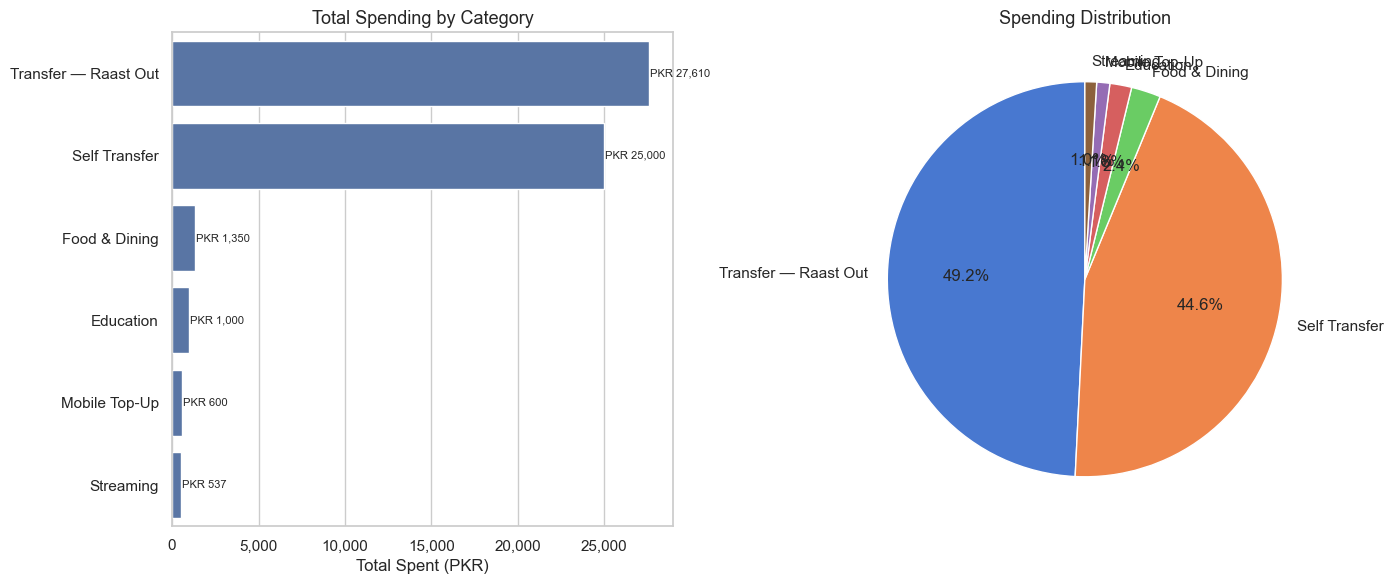

In [17]:
from finance_analyzer.visualizer import plot_spending_by_category

plot_spending_by_category(df_categorized)

# Run anomaly detection

In [18]:
from finance_analyzer.ml import detect_anomalies, get_anomaly_report
df_final = detect_anomalies(df_categorized, contamination = 0.05)

# Quick check — how many anomalies found?
print(f"Total transactions: {len(df_final)}")
print(f"Anomalies flagged: {df_final['is_anomaly'].sum()}")

Total transactions: 60
Anomalies flagged: 3


# Seeing anomaly report

In [19]:
get_anomaly_report(df_final)

,timestamp,description,amount,category,anomaly_score,reason
0,2026-01-02 00:42:00,Incoming fund transfer from Iqra Irfan,25000.0,Transfer — Raast In,-0.096051,"Unusually large amount, Unusual time (0:00)"
32,2026-02-02 10:47:00,Incoming fund transfer from Durdana Iram Irfan,25000.0,Transfer — Raast In,-0.069977,Unusually large amount
15,2026-01-16 01:41:00,Incoming fund transfer from Muhammad Musa Riaz,1630.0,Self Transfer,-0.016686,Unusual time (1:00)


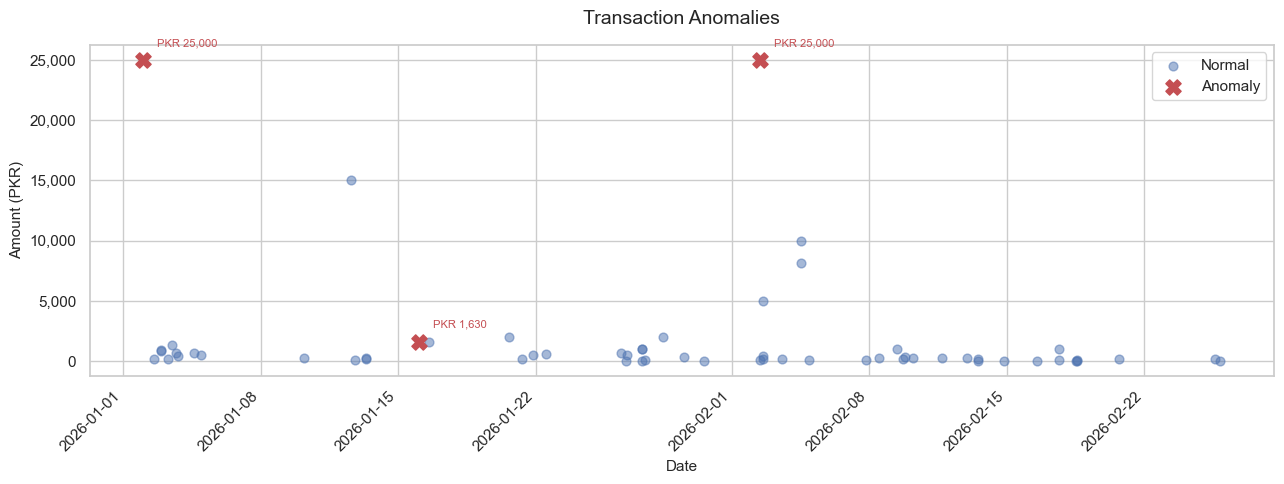

In [20]:
from finance_analyzer.visualizer import plot_anomalies

plot_anomalies(df_final)

# Prepare and train

In [21]:
from finance_analyzer.ml import prepare_monthly_features, train_spending_model

monthly_features = prepare_monthly_features(df_final)

# See what the training data looks like
print(monthly_features[["month_label", "total_spent", "month_index"]])

  month_label  total_spent  month_index
0    Jan 2026     28670.31            1
1    Feb 2026     27426.54            2


# Train the Model

In [22]:
model, metadata = train_spending_model(monthly_features)

print(f"Monthly trend:     PKR {metadata['slope']:,.0f} per month")
print(f"Avg forecast error: PKR {metadata['avg_loo_error']:,.0f}")
print(f"Months trained on: {metadata['num_months_trained']}")

Monthly trend:     PKR -1,244 per month
Avg forecast error: PKR 1,244
Months trained on: 2


# Generate Forecast

In [23]:
from finance_analyzer.ml import forecast_next_months

forecast_df = forecast_next_months(model, monthly_features, n_months=3)
forecast_df

,month_label,predicted_spending,is_forecast
0,Jan 2026,28670.31,False
1,Feb 2026,27426.54,False
2,Mar 2026,26182.77,True
3,Apr 2026,24939.00,True
4,May 2026,23695.23,True


# Visualize

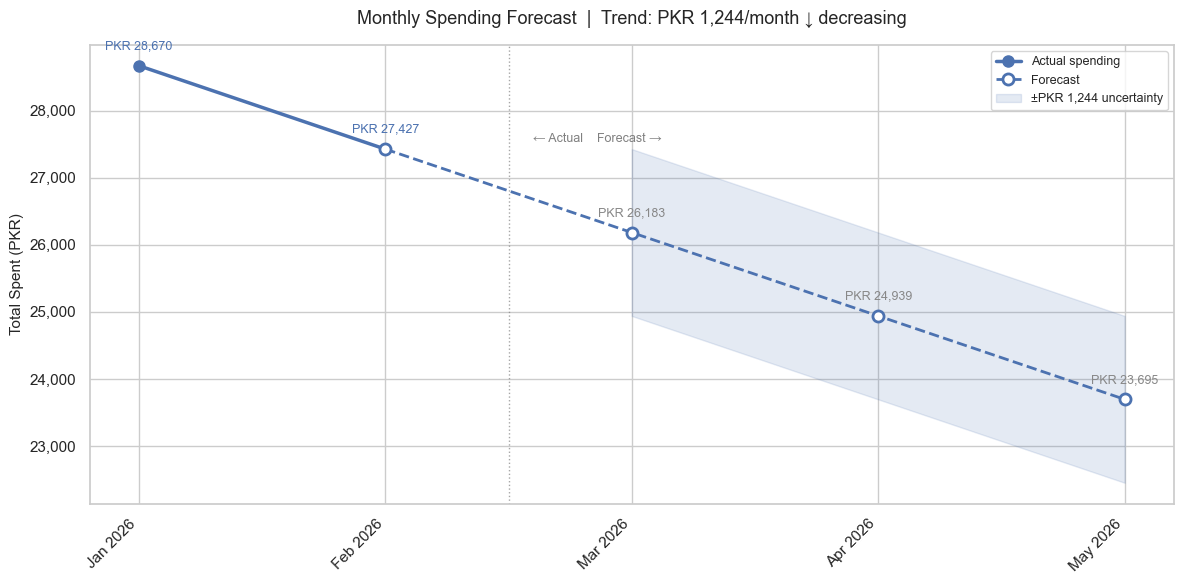

In [24]:
from finance_analyzer.visualizer import plot_forecast

plot_forecast(forecast_df, metadata)